# Grid Engine Example: Tennessee 161kv Network

This Jupyter notebook showcases a real world example of grid_engine being applied to a real world power grid.

In this example, the Tennessee 161kv power grid was chosen, for a few reasons.

1) The 161kv grid was specifically chosen since it isn't recorded to the same strict detail as the 500kv grid, highlighting the need for heavy data cleaning/imputation functions which the library showcases.
2) Tennessee is where I earned my degree, so I am simply more familiar with the area.

In [ ]:
import pandas as pd
import geopandas as gpd

### Load and Tailor Data

The OSM data collected is from GeoFabrik, and using the OSM command line tool I filtered out anything that wasn't part of the powergrid (e.g. roads, buildings, etc).



In [ ]:
from grid_engine.ingestion import PowerHandler

handler = PowerHandler()
handler.apply_file("../data/tennessee_power.osm.pbf", locations=True)
lines = [w for w in handler.ways if w['type'] == 'line']
subs = [w for w in handler.ways if w['type'] == 'substation']

In [ ]:
from grid_engine.ingestion import ways_to_geodataframe
line_gdf = ways_to_geodataframe(lines)
substations_gdf = ways_to_geodataframe(subs)

In [ ]:
line_gdf = line_gdf.copy()
substation_gdf = substations_gdf.copy()

In [ ]:
# 1. Convert 'cables' to numeric float (invalid strings become NaN)
cables_numeric = pd.to_numeric(line_gdf['cables'], errors='coerce')

# 2. Vectorized fill: if 'counts' is null, use cables / 3
line_gdf['counts'] = line_gdf['counts'].fillna(cables_numeric / 3)

In [ ]:
line_gdf

,id,name,type,voltage,coords,node_refs,geometry,counts,cables,osm_type,tags
0,6758473,NaN,line,69000,"[(-87.4066518, 36.0933041), (-87.406419, 36.09...","[11225106357, 11225106356, 2142463289, 2142463...","LINESTRING (-87.40665 36.0933, -87.40642 36.09...",1,3,way,"{'cables': '3', 'circuits': '1', 'operator': '..."
1,6760644,NaN,line,161000,"[(-87.0831674, 36.1295822), (-87.0851681, 36.1...","[1231331389, 2142509277, 2142509254, 214250922...","LINESTRING (-87.08317 36.12958, -87.08517 36.1...",1,3,way,"{'cables': '3', 'circuits': '1', 'operator': '..."
2,6761908,NaN,line,69000,"[(-87.2244892, 36.3189197), (-87.2256724, 36.3...","[2142662391, 2142662379, 2142662374]","LINESTRING (-87.22449 36.31892, -87.22567 36.3...",2,6,way,"{'cables': '6', 'circuits': '2', 'operator': '..."
3,6787020,NaN,line,69000,"[(-88.3423608, 36.3139434), (-88.3429616, 36.3...","[11195600198, 2146374880, 2146374875, 21463748...","LINESTRING (-88.34236 36.31394, -88.34296 36.3...",1,3,way,"{'cables': '3', 'circuits': '1', 'operator': '..."
4,6787774,NaN,line,69000,"[(-88.3705184, 36.2785264), (-88.3713739, 36.2...","[2146374702, 2146374742, 9011233139, 901123313...","LINESTRING (-88.37052 36.27853, -88.37137 36.2...",1,3,way,"{'cables': '3', 'circuits': '1', 'operator': '..."
...,...,...,...,...,...,...,...,...,...,...,...
5611,1518350634,NaN,line,24940,"[(-86.5370128, 36.2592639), (-86.5370097, 36.2...","[13858108642, 13858108638, 13858108639, 138581...","LINESTRING (-86.53701 36.25926, -86.53701 36.2...",NaN,NaN,way,"{'line': 'busbar', 'power': 'line', 'voltage':..."
5612,1518350635,NaN,line,161000,"[(-86.5366291, 36.2592277), (-86.536621, 36.25...","[13858108644, 13858108628, 13858108629, 138581...","LINESTRING (-86.53663 36.25923, -86.53662 36.2...",NaN,NaN,way,"{'line': 'busbar', 'power': 'line', 'voltage':..."
5613,1518350636,NaN,line,24940,"[(-86.5370909, 36.2592244), (-86.5370884, 36.2...","[13858108636, 13858108616, 13858108637, 138581...","LINESTRING (-86.53709 36.25922, -86.53709 36.2...",NaN,NaN,way,"{'line': 'busbar', 'power': 'line', 'voltage':..."
5614,1518350637,NaN,line,161000,"[(-86.5368814, 36.2595043), (-86.5366822, 36.2...","[11220520465, 13858108634, 13858108635, 138581...","LINESTRING (-86.53688 36.2595, -86.53668 36.25...",NaN,NaN,way,"{'line': 'busbar', 'power': 'line', 'voltage':..."


In [ ]:
line_gdf['type_tag'] = line_gdf['tags'].apply(lambda x: x.get('line', None) if isinstance(x, dict) else None)
line_gdf = line_gdf[line_gdf['type_tag'] != 'busbar']
line_gdf.drop(columns=['type_tag'], inplace=True)

In [ ]:
line_gdf.drop(columns=['cables', 'osm_type', 'tags'], inplace=True)

The number of missing circuit counts by line is still something to note. As the project is a work in progress, I expect this number to diminish as more sophisticated imputations methods are used.

In [ ]:
line_gdf['counts'].isna().sum()

np.int64(332)

In [ ]:
substation_gdf.drop(columns=['osm_type', 'tags'], inplace=True)

Below are the final tailored datasets, stored as pandas dataframes and with the specific features needed to create a graph representation of this power grid.

In [ ]:
line_gdf

In [ ]:
substation_gdf

,id,name,type,voltage,coords,node_refs,geometry
0,27798703,NaN,substation,161000,"[(-86.3979537, 36.3155827), (-86.3977819, 36.3...","[305216755, 1701905350, 305216757, 2038770365,...","LINESTRING (-86.39795 36.31558, -86.39778 36.3..."
1,50278639,NaN,substation,161000,"[(-89.8698757, 35.1225974), (-89.8699027, 35.1...","[638891351, 638891352, 638891353, 638891354, 6...","LINESTRING (-89.86988 35.1226, -89.8699 35.121..."
2,53210862,Cummings Substation,substation,161000,"[(-85.3894057, 35.0164871), (-85.389806, 35.01...","[673458479, 673458481, 673458482, 673458483, 6...","LINESTRING (-85.38941 35.01649, -85.38981 35.0..."
3,53624949,North Nashville Substation,substation,161000,"[(-86.7136053, 36.2773582), (-86.7124169, 36.2...","[2678406901, 2678406897, 11552893164, 67729119...","LINESTRING (-86.71361 36.27736, -86.71242 36.2..."
4,80436792,Sequoyah Substation,substation,500000,"[(-85.0944382, 35.228242), (-85.0929308, 35.22...","[938599790, 938599789, 938599791, 938599792, 9...","LINESTRING (-85.09444 35.22824, -85.09293 35.2..."
...,...,...,...,...,...,...,...
1423,1518332749,NaN,substation,24940,"[(-86.8690743, 35.9058431), (-86.8690875, 35.9...","[13857813265, 13857813264, 13857813263, 138578...","LINESTRING (-86.86907 35.90584, -86.86909 35.9..."
1424,1518335133,La Vergne Substation,substation,161000;24940,"[(-86.5770413, 35.9824362), (-86.5762635, 35.9...","[13857829043, 13857829042, 13857829041, 138578...","LINESTRING (-86.57704 35.98244, -86.57626 35.9..."
1425,1518336291,NaN,substation,24940,"[(-86.4908649, 35.8281041), (-86.4910006, 35.8...","[13857837854, 13857837853, 13857837852, 138578...","LINESTRING (-86.49086 35.8281, -86.491 35.8279..."
1426,1518346699,NaN,substation,24940,"[(-86.3223021, 36.2163037), (-86.3223357, 36.2...","[13858084532, 13858084531, 13858084530, 138580...","LINESTRING (-86.3223 36.2163, -86.32234 36.216..."


## Grid Engine

Utilizing the GridEngine through its facade is easy. You just need to import the class, pass your dataframes, choose a m_buffer to give the OSM data some leeway in plotting, and select a subset of voltages.

In [ ]:
from grid_engine.engine import GridEngine

In [ ]:
GE = GridEngine(line_gdf, substation_gdf, m_buffer=100, voltage_selection=[161000])
GE.run()

The view function works beautifully for toy datasets, but not so much for real world data. A better system to visualize the network quickly is next on the list. For the time being, there is a placeholder function below to generate an html file and cleanly view the network.

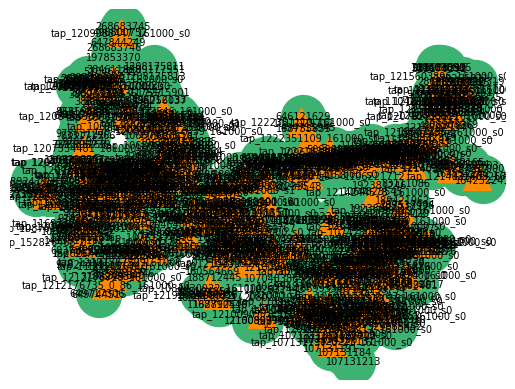

In [ ]:
GE.view()

In [ ]:
print("Substation-Line Adjacency Matrix:")
print(GE.substation_line_adjacency)

print("String-String Adjacency Matrix:")
print(GE.string_string_adjacency)

print("Substation-String Adjacency Matrix:")
print(GE.substation_string_adjacency)

Substation-Line Adjacency Matrix:
{1231388451161000: 107040337, 9873448054161000: 773575199, 11323192029161000: 189217850, 11291172374161000: 108190192, 11296021652161000: 1219053268, 1756860098161000: 164024536, 1758046382161000: 164024536, 1756860095161000: 164024536, 1242126445161000: 108234159, 201757127161000: 108234159, 11286834864161000: 188908067, 11296021851161000: 108190192, 2291778026161000: 220059648, 3836100470161000: 380267354, 11211835572161000: 1210215228, 11196522137161000: 649290911, 11203386964161000: 205745704, 2158073762161000: 205822926, 11214981089161000: 189583417, 11298469244161000: 108650262, 11194620367161000: 1208130521, 11299455624161000: 108570609, 9873448062161000: 1058690807, 11294899621161000: 108234158, 13332678641161000: 1453762483, 11335368973161000: 846218406, 11296021777161000: 188755857, 11194947171161000: 1208175810, 7658829653161000: 208025294, 1235805317161000: 107539519, 11228493365161000: 107555725, 10883029542161000: 189421962, 1129602200016

### View Graph

This is an AI generated placeholder to view the generated network, whilst cleaner more sophisticated viewing methods are being produced.

In [ ]:
import pandas as pd
import networkx as nx
from pyvis.network import Network


#TODO(AI Placeholder): This is a temporary AI Placeholder function, for demonstration purposes, replace with better version
def render_interactive_grid_html(
    G: nx.Graph, 
    substations_gdf: gpd.GeoDataFrame, 
    output_html: str = "substation_network.html"
):
    """Converts a NetworkX graph into an interactive HTML network visualization using PyVis.
    Supports MultiGraph parallel circuits and robust ID-to-name mapping.
    """
    if G is None or len(G.nodes) == 0:
        print("Graph is empty!")
        return

    # 1. Robust ID-to-Name Mapping
    sub_name_map = {}
    if not substations_gdf.empty:
        # Find the best candidate column for ID matching
        id_candidates = ['id', 'osmid', 'substation_id', 'osm_id']
        id_col = next((col for col in id_candidates if col in substations_gdf.columns), None)
        
        for idx, row in substations_gdf.iterrows():
            # Fallback to index if no explicit ID column exists
            s_id = str(row[id_col]) if id_col and pd.notna(row[id_col]) else str(idx)
            s_name = str(row['name']) if ('name' in row and pd.notna(row['name'])) else s_id
            sub_name_map[s_id] = s_name

    # 2. Initialize PyVis Network
    net = Network(height="850px", width="100%", bgcolor="#1a1a1a", font_color="white", notebook=False)

    # 3. Enable physics engine
    net.force_atlas_2based(
        gravity=-50,
        central_gravity=0.01,
        spring_length=100,
        spring_strength=0.08,
        damping=0.4
    )

    # 4. Add Nodes
    for node_id in G.nodes():
        node_str = str(node_id)
        
        if node_str.startswith('tap_'):
            label = node_str
            color = "#ff7f0e"
            title = f"<b>Synthetic Tap Point</b><br>ID: {node_str}"
            shape = "triangle"
        else:
            sub_name = sub_name_map.get(node_str, node_str)
            label = sub_name
            color = "#2ca02c"
            title = f"<b>Substation:</b> {sub_name}<br><b>ID:</b> {node_str}<br><b>Degree:</b> {G.degree(node_id)}"
            shape = "dot"

        net.add_node(
            node_str, 
            label=label, 
            title=title, 
            color=color, 
            shape=shape,
            size=20
        )

    # 5. FIX: Iterate over keys=True so MultiGraph parallel circuits don't get dropped
    # Check if graph is a MultiGraph or MultiDiGraph
    is_multi = isinstance(G, (nx.MultiGraph, nx.MultiDiGraph))
    
    edge_iterator = G.edges(keys=True, data=True) if is_multi else [(u, v, 0, data) for u, v, data in G.edges(data=True)]

    for u, v, key, data in edge_iterator:
        v_val = str(data.get("voltage", ""))
        edge_color = "#d62728" if ("500" in v_val) else "#1f77b4"
        edge_title = f"Voltage: {v_val if v_val else 'Unknown'}"

        net.add_edge(
            str(u), 
            str(v), 
            color=edge_color, 
            width=3, 
            title=edge_title
        )

    # 6. Save and export
    net.write_html(output_html)
    print(f"Interactive network saved successfully to {output_html}")

In [ ]:
render_interactive_grid_html(GE.networkx_graph, substation_gdf, "visualizations/substation_network.html")

Interactive network saved successfully to substation_network.html
